# Módulo 02: Machine Learning

**(2A) Regresión:** Forecast de demanda (Random Forest + XGBoost)

**(2B) Clasificación:** Riesgo de desabasto (SMOTE + Random Forest)

**(2C) Interpretabilidad:** SHAP values + Feature Importance

Este notebook usa los datos del **Módulo 01**. Asegúrate de correr primero las celdas de `generate_data()`.

In [1]:
!pip install ortools scikit-learn xgboost shap imbalanced-learn matplotlib pandas numpy -q
print('Dependencias instaladas')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 12.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
Dependencias instaladas


## Imports y configuración

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             confusion_matrix, roc_auc_score, f1_score,
                             ConfusionMatrixDisplay, roc_curve)
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

SEED = 42

# ── Paleta Ternium ──────────────────────────────
TERNIUM = {
    'orange':     '#F5A800',
    'red':        '#E3000F',
    'black':      '#1A1A1A',
    'gray':       '#6B6B6B',
    'light_gray': '#D6D6D6',
    'dark_gray':  '#3D3D3D',
    'bg':         '#FFFFFF',
    'grid':       '#EEEEEE',
}
PALETTE = ['#F5A800', '#E3000F', '#3D3D3D', '#6B6B6B', '#D6D6D6']

def _base_style(ax, fig):
    ax.set_facecolor(TERNIUM['bg'])
    fig.patch.set_facecolor(TERNIUM['bg'])
    ax.grid(color=TERNIUM['grid'], linewidth=0.7, linestyle='--', zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(TERNIUM['light_gray'])
    ax.spines['bottom'].set_color(TERNIUM['light_gray'])
    ax.tick_params(colors=TERNIUM['gray'], labelsize=9)
    ax.xaxis.label.set_color(TERNIUM['dark_gray'])
    ax.yaxis.label.set_color(TERNIUM['dark_gray'])

print('Imports OK y Paleta Ternium cargada')

Imports OK y Paleta Ternium cargada


## Datos del Módulo 01

(Reutilizamos los mismos 20 puntos de demanda generados en el Módulo 01.)

In [3]:
# ── Copiar aquí la función generate_data() del Módulo 01 ──
def generate_data(seed=42):
    rng = np.random.default_rng(seed)
    n_warehouses    = 5
    n_demand_points = 20
    warehouse_coords = rng.uniform(0, 100, size=(n_warehouses, 2))
    demand_coords    = rng.uniform(0, 100, size=(n_demand_points, 2))
    costs = np.zeros((n_warehouses, n_demand_points))
    for i in range(n_warehouses):
        for j in range(n_demand_points):
            dist = np.linalg.norm(warehouse_coords[i] - demand_coords[j])
            costs[i, j] = round(dist * rng.uniform(0.8, 1.2), 2)
    capacities = rng.integers(500, 2001, size=n_warehouses)
    demands    = rng.integers(50, 301,  size=n_demand_points)
    return {
        'n_warehouses': n_warehouses, 'n_demand_points': n_demand_points,
        'costs': costs, 'capacities': capacities, 'demands': demands,
        'warehouse_coords': warehouse_coords, 'demand_coords': demand_coords,
        'warehouse_names': [f'Almacén {i+1}' for i in range(n_warehouses)],
        'demand_names':    [f'Punto {j+1}'   for j in range(n_demand_points)],
    }

data_m01 = generate_data()
print(f'Puntos de demanda: {data_m01["n_demand_points"]}')
print(f'Demandas base: {data_m01["demands"]}')

Puntos de demanda: 20
Demandas base: [ 85 125 189 129  77 217 218  79 120 111 215 233 232 285 242 130  77 204
 279 294]


## 2A: Generación de Serie Temporal

Creamos 52 semanas de demanda para cada uno de los 20 puntos, con **tendencia + estacionalidad + ruido**.

In [4]:
def generate_time_series(data_m01, n_weeks=52, seed=SEED):
    rng   = np.random.default_rng(seed)
    weeks = np.arange(1, n_weeks + 1)
    records = []
    for idx, (name, base) in enumerate(zip(data_m01['demand_names'], data_m01['demands'])):
        trend      = base + weeks * rng.uniform(0.1, 0.5)
        seasonality = 15 * np.sin(2 * np.pi * weeks / 52) + 8 * np.sin(4 * np.pi * weeks / 52)
        noise      = rng.normal(0, base * 0.08, size=n_weeks)
        demand     = np.clip(trend + seasonality + noise, 10, None).round(1)
        for w, d in zip(weeks, demand):
            records.append({'punto': name, 'punto_id': idx, 'semana': w,
                            'demanda': d, 'base_demand': base})
    df = pd.DataFrame(records)
    print(f'Serie temporal: {len(df)} registros | {df["punto"].nunique()} puntos × {n_weeks} semanas')
    return df

df_ts = generate_time_series(data_m01)
display(df_ts.head(10))

Serie temporal: 1040 registros | 20 puntos × 52 semanas


,punto,punto_id,semana,demanda,base_demand
0,Punto 1,0,1,82.1,85
1,Punto 1,0,2,98.2,85
2,Punto 1,0,3,103.2,85
3,Punto 1,0,4,86.9,85
4,Punto 1,0,5,94.2,85
5,Punto 1,0,6,106.2,85
6,Punto 1,0,7,104.9,85
7,Punto 1,0,8,108.0,85
8,Punto 1,0,9,102.8,85
9,Punto 1,0,10,114.4,85


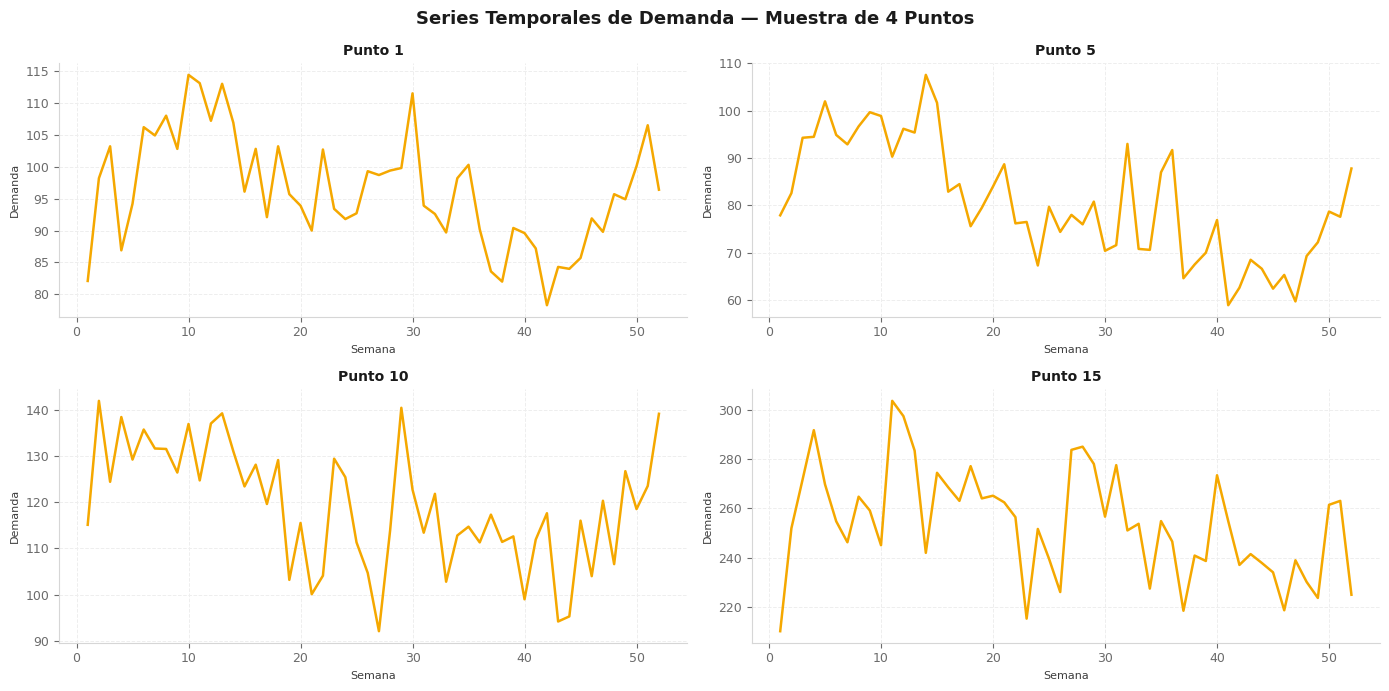

Guardado: series_temporales.png


In [5]:
# Visualización rápida de 4 puntos
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.patch.set_facecolor(TERNIUM['bg'])
fig.suptitle('Series Temporales de Demanda — Muestra de 4 Puntos',
             fontsize=13, fontweight='bold', color=TERNIUM['black'])
puntos_muestra = [0, 4, 9, 14]
for ax, pid in zip(axes.flatten(), puntos_muestra):
    _base_style(ax, fig)
    pt = df_ts[df_ts['punto_id'] == pid]
    ax.plot(pt['semana'], pt['demanda'], color=TERNIUM['orange'], linewidth=1.8)
    ax.set_title(f'Punto {pid+1}', color=TERNIUM['black'], fontsize=10, fontweight='bold')
    ax.set_xlabel('Semana', fontsize=8)
    ax.set_ylabel('Demanda', fontsize=8)
plt.tight_layout()
plt.savefig('series_temporales.png', dpi=150, bbox_inches='tight', facecolor=TERNIUM['bg'])
plt.show()
print('Guardado: series_temporales.png')

## 2A: Feature Engineering



Creamos lags, rolling stats y features temporales cíclicas.

In [6]:
REGRESSION_FEATURES = [
    'punto_id', 'semana', 'base_demand',
    'lag_1', 'lag_2', 'lag_3', 'lag_4',
    'roll_mean_3', 'roll_mean_4', 'roll_std_3', 'roll_std_4',
    'semana_sin', 'semana_cos', 'trimestre'
]

def build_features(df):
    df = df.sort_values(['punto_id', 'semana']).copy()
    for lag in [1, 2, 3, 4]:
        df[f'lag_{lag}'] = df.groupby('punto_id')['demanda'].shift(lag)
    for w in [3, 4]:
        df[f'roll_mean_{w}'] = df.groupby('punto_id')['demanda'] \
                                  .transform(lambda x: x.shift(1).rolling(w).mean())
        df[f'roll_std_{w}']  = df.groupby('punto_id')['demanda'] \
                                  .transform(lambda x: x.shift(1).rolling(w).std())
    df['semana_sin'] = np.sin(2 * np.pi * df['semana'] / 52)
    df['semana_cos'] = np.cos(2 * np.pi * df['semana'] / 52)
    df['trimestre']  = ((df['semana'] - 1) // 13 + 1).astype(int)
    return df.dropna().reset_index(drop=True)

df_feat = build_features(df_ts)
print(f'Dataset con features: {df_feat.shape}')
display(df_feat[REGRESSION_FEATURES + ['demanda']].head())

Dataset con features: (960, 16)


,punto_id,semana,base_demand,lag_1,lag_2,lag_3,lag_4,roll_mean_3,roll_mean_4,roll_std_3,roll_std_4,semana_sin,semana_cos,trimestre,demanda
0,0,5,85,86.9,103.2,98.2,82.1,96.100000,92.600,8.350449,9.771728,0.568065,0.822984,1,94.2
1,0,6,85,94.2,86.9,103.2,98.2,94.766667,95.625,8.164762,6.883979,0.663123,0.748511,1,106.2
2,0,7,85,106.2,94.2,86.9,103.2,95.766667,97.625,9.744913,8.781942,0.748511,0.663123,1,104.9
3,0,8,85,104.9,106.2,94.2,86.9,101.766667,98.050,6.585084,9.174058,0.822984,0.568065,1,108.0
4,0,9,85,108.0,104.9,106.2,94.2,106.366667,103.325,1.556706,6.214700,0.885456,0.464723,1,102.8


## 2A: Walk-Forward Validation

Entrenamos con semanas 1–42 y evaluamos en semanas 43–52 (sin data leakage).

In [7]:
weeks  = sorted(df_feat['semana'].unique())
cutoff = weeks[-10]   # últimas 10 semanas = test

train = df_feat[df_feat['semana'] <  cutoff]
test  = df_feat[df_feat['semana'] >= cutoff]

X_train, y_train = train[REGRESSION_FEATURES], train['demanda']
X_test,  y_test  = test[REGRESSION_FEATURES],  test['demanda']

print(f'Train: {len(train)} registros | Test: {len(test)} registros')
print(f'Semanas train: {train["semana"].min()}–{train["semana"].max()}')
print(f'Semanas test : {test["semana"].min()}–{test["semana"].max()}')

Train: 760 registros | Test: 200 registros
Semanas train: 5–42
Semanas test : 43–52


In [8]:
# ── Entrenar modelos ─────────────────────────────────
rf_model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=SEED, n_jobs=-1)
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05,
                               random_state=SEED, verbosity=0)

rf_model.fit(X_train,  y_train)
xgb_model.fit(X_train, y_train)

rf_preds  = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

def metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'[{name}] MAE={mae:.2f} | RMSE={rmse:.2f} | MAPE={mape:.2f}%')
    return {'mae': round(mae,2), 'rmse': round(rmse,2), 'mape': round(mape,2)}

rf_metrics  = metrics(y_test, rf_preds,  'Random Forest')
xgb_metrics = metrics(y_test, xgb_preds, 'XGBoost')

reg_results = {
    'Random Forest': {'model': rf_model,  'preds': rf_preds,  'y_test': y_test.values,
                      'test_df': test, **rf_metrics},
    'XGBoost':       {'model': xgb_model, 'preds': xgb_preds, 'y_test': y_test.values,
                      'test_df': test, **xgb_metrics},
}

[Random Forest] MAE=13.86 | RMSE=18.36 | MAPE=7.95%
[XGBoost] MAE=14.40 | RMSE=18.82 | MAPE=8.43%


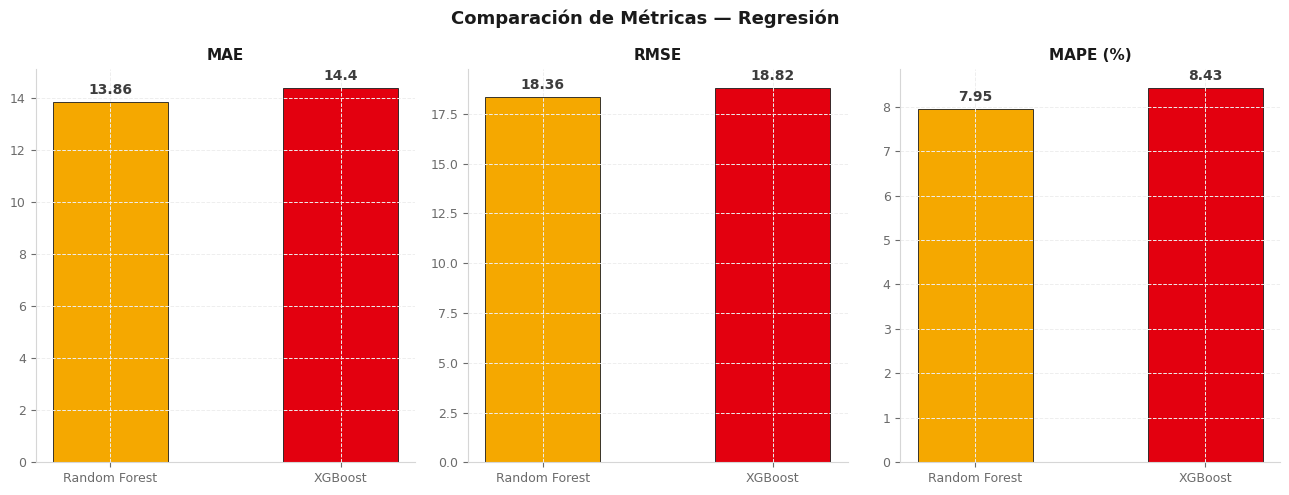

Guardado: metrics_comparison.png


In [9]:
# ── Gráfica: métricas comparadas ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.patch.set_facecolor(TERNIUM['bg'])
fig.suptitle('Comparación de Métricas — Regresión', fontsize=13, fontweight='bold', color=TERNIUM['black'])
model_names = ['Random Forest', 'XGBoost']
bar_colors  = [TERNIUM['orange'], TERNIUM['red']]
for ax, (metric, label) in zip(axes, [('mae','MAE'), ('rmse','RMSE'), ('mape','MAPE (%)')]):
    _base_style(ax, fig)
    vals = [reg_results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=bar_colors, edgecolor=TERNIUM['black'], linewidth=0.6, width=0.5)
    ax.set_title(label, color=TERNIUM['black'], fontsize=11, fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{val}', ha='center', color=TERNIUM['dark_gray'], fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight', facecolor=TERNIUM['bg'])
plt.show()
print('Guardado: metrics_comparison.png')

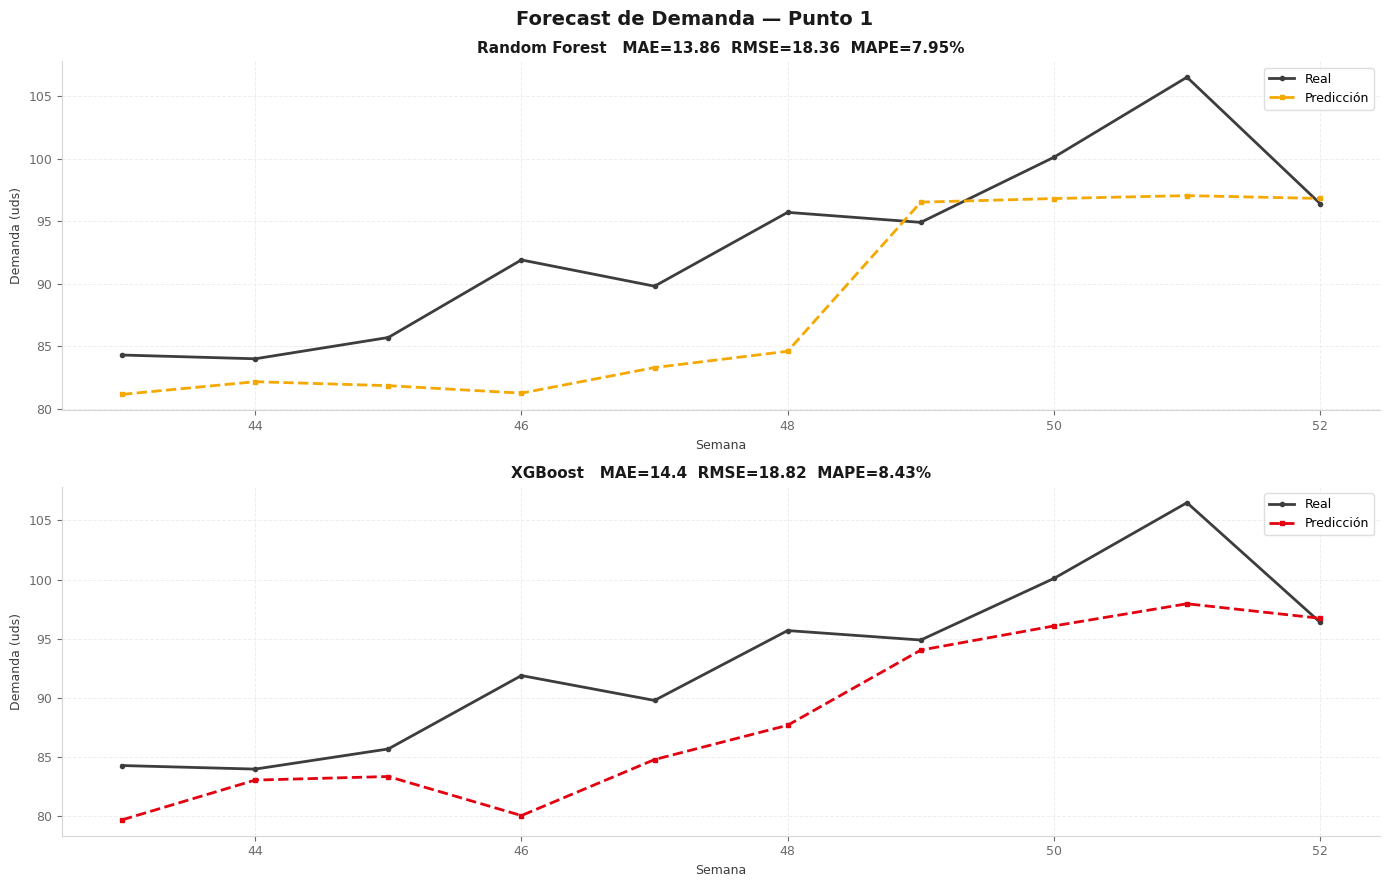

Guardado: forecast.png


In [10]:
# ── Gráfica: forecast vs real (Punto 1) ──────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.patch.set_facecolor(TERNIUM['bg'])
fig.suptitle('Forecast de Demanda — Punto 1', fontsize=14, fontweight='bold', color=TERNIUM['black'])
colors_m = {'Random Forest': TERNIUM['orange'], 'XGBoost': TERNIUM['red']}
for ax, (mname, res) in zip(axes, reg_results.items()):
    _base_style(ax, fig)
    pt = test[test['punto_id'] == 0].sort_values('semana')
    pt_idx = [list(test.index).index(i) for i in pt.index]
    preds_pt = res['preds'][pt_idx]
    ax.plot(pt['semana'].values, pt['demanda'].values,
            color=TERNIUM['dark_gray'], lw=2, label='Real', marker='o', markersize=3)
    ax.plot(pt['semana'].values, preds_pt,
            color=colors_m[mname], lw=2, ls='--', label='Predicción', marker='s', markersize=3)
    ax.set_title(f"{mname}   MAE={res['mae']}  RMSE={res['rmse']}  MAPE={res['mape']}%",
                 color=TERNIUM['black'], fontsize=11, fontweight='bold')
    ax.set_xlabel('Semana', fontsize=9)
    ax.set_ylabel('Demanda (uds)', fontsize=9)
    ax.legend(fontsize=9, edgecolor=TERNIUM['light_gray'])
plt.tight_layout()
plt.savefig('forecast.png', dpi=150, bbox_inches='tight', facecolor=TERNIUM['bg'])
plt.show()
print('Guardado: forecast.png')

## 2B: Clasificación: Riesgo de Desabasto

Generamos un dataset con features conectadas al Módulo 01 y aplicamos **SMOTE** para balancear clases.

In [11]:
def generate_classification_data(data_m01, seed=SEED):
    rng = np.random.default_rng(seed)
    n   = 600
    coords_w = data_m01['warehouse_coords']
    coords_d = data_m01['demand_coords']
    dist_to_nearest = [min([np.linalg.norm(coords_w[i] - coords_d[j])
                            for i in range(data_m01['n_warehouses'])])
                       for j in range(data_m01['n_demand_points'])]
    avg_dist = np.mean(dist_to_nearest)

    stock_actual       = rng.uniform(50,  500, n)
    lead_time          = rng.uniform(1,   14,  n)
    demanda_proyectada = rng.uniform(50,  350, n)
    distancia_almacen  = rng.uniform(min(dist_to_nearest), max(dist_to_nearest)*1.2, n)
    cobertura          = stock_actual / (demanda_proyectada + 1e-6)

    riesgo = (
        ((cobertura < 1.2) & (lead_time > 7)) |
        ((distancia_almacen > avg_dist * 1.1) & (stock_actual < 150))
    ).astype(int)
    flip = rng.choice(n, size=int(n*0.05), replace=False)
    riesgo[flip] = 1 - riesgo[flip]

    df = pd.DataFrame({
        'stock_actual': stock_actual.round(1), 'lead_time': lead_time.round(1),
        'demanda_proyectada': demanda_proyectada.round(1),
        'distancia_almacen': distancia_almacen.round(2),
        'cobertura': cobertura.round(3), 'riesgo_alto': riesgo,
    })
    print(df['riesgo_alto'].value_counts().rename({0:'Riesgo bajo', 1:'Riesgo alto'}).to_string())
    return df

df_cls = generate_classification_data(data_m01)
display(df_cls.head())

riesgo_alto
Riesgo bajo    404
Riesgo alto    196


,stock_actual,lead_time,demanda_proyectada,distancia_almacen,cobertura,riesgo_alto
0,398.3,7.2,219.9,37.64,1.811,0
1,247.5,10.9,215.3,38.40,1.150,1
2,436.4,12.7,298.6,10.31,1.462,0
3,363.8,10.4,263.2,42.43,1.382,0
4,92.4,13.5,58.0,41.35,1.593,1


In [12]:
CLASS_FEATURES = ['stock_actual', 'lead_time', 'demanda_proyectada', 'distancia_almacen', 'cobertura']
X = df_cls[CLASS_FEATURES]
y = df_cls['riesgo_alto']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f'Antes SMOTE — {y_train_c.value_counts().to_dict()}')
smote = SMOTE(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train_c, y_train_c)
print(f'Después SMOTE — {pd.Series(y_train_res).value_counts().to_dict()}')

cls_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=SEED, n_jobs=-1)
cls_model.fit(X_train_res, y_train_res)

preds_c = cls_model.predict(X_test_c)
proba_c = cls_model.predict_proba(X_test_c)[:, 1]
roc_auc = roc_auc_score(y_test_c, proba_c)
f1      = f1_score(y_test_c, preds_c)
cm      = confusion_matrix(y_test_c, preds_c)

print(f'ROC-AUC = {roc_auc:.4f} | F1 = {f1:.4f}')
print(f'Matriz de confusión:\n{cm}')

Antes SMOTE — {0: 323, 1: 157}
Después SMOTE — {0: 323, 1: 323}
ROC-AUC = 0.9186 | F1 = 0.8219
Matriz de confusión:
[[77  4]
 [ 9 30]]


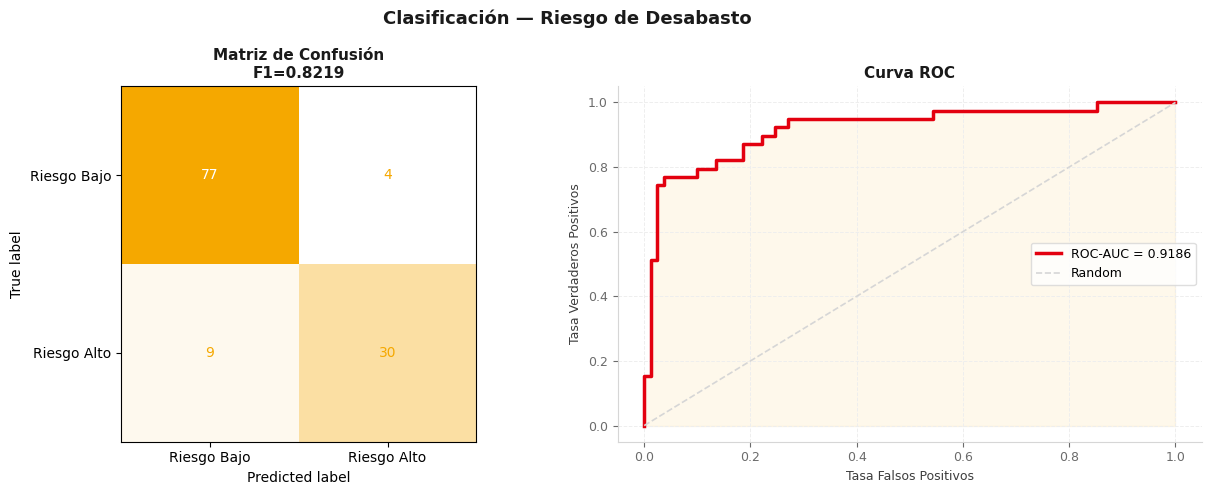

Guardado: classification_report.png


In [13]:
# ── Matriz de confusión + Curva ROC ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(TERNIUM['bg'])
fig.suptitle('Clasificación — Riesgo de Desabasto', fontsize=13, fontweight='bold', color=TERNIUM['black'])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Riesgo Bajo', 'Riesgo Alto'])
disp.plot(ax=axes[0], colorbar=False,
          cmap=plt.cm.colors.LinearSegmentedColormap.from_list('t', [TERNIUM['bg'], TERNIUM['orange']]))
axes[0].set_title(f'Matriz de Confusión\nF1={f1:.4f}', color=TERNIUM['black'], fontsize=11, fontweight='bold')

_base_style(axes[1], fig)
fpr, tpr, _ = roc_curve(y_test_c, proba_c)
axes[1].plot(fpr, tpr, color=TERNIUM['red'], lw=2.5, label=f'ROC-AUC = {roc_auc:.4f}')
axes[1].plot([0,1],[0,1], color=TERNIUM['light_gray'], ls='--', lw=1.2, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.08, color=TERNIUM['orange'])
axes[1].set_title('Curva ROC', color=TERNIUM['black'], fontsize=11, fontweight='bold')
axes[1].set_xlabel('Tasa Falsos Positivos', fontsize=9)
axes[1].set_ylabel('Tasa Verdaderos Positivos', fontsize=9)
axes[1].legend(fontsize=9, edgecolor=TERNIUM['light_gray'])
plt.tight_layout()
plt.savefig('classification_report.png', dpi=150, bbox_inches='tight', facecolor=TERNIUM['bg'])
plt.show()
print('Guardado: classification_report.png')

## 2C: Interpretabilidad: Feature Importance + SHAP

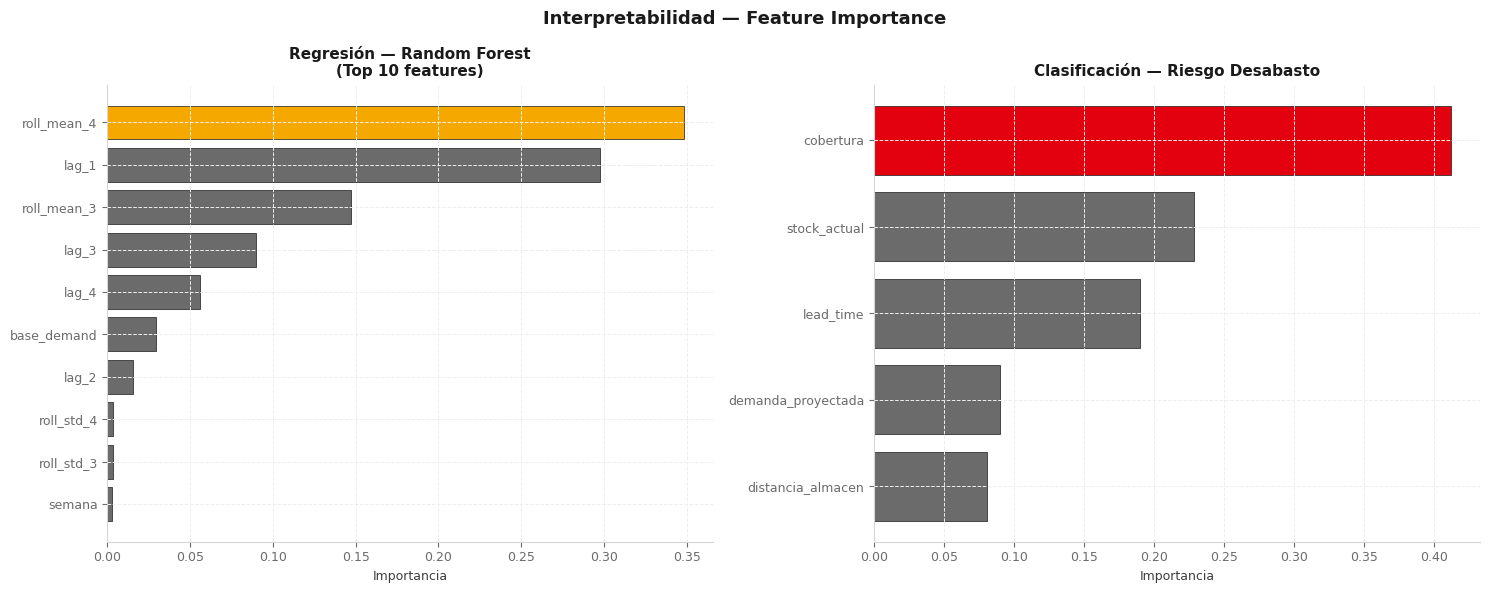

Guardado: feature_importance.png


In [14]:
# ── Feature Importance ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(TERNIUM['bg'])
fig.suptitle('Interpretabilidad — Feature Importance', fontsize=13, fontweight='bold', color=TERNIUM['black'])

imp_reg = pd.Series(rf_model.feature_importances_, index=REGRESSION_FEATURES).sort_values(ascending=True).tail(10)
_base_style(axes[0], fig)
colors_r = [TERNIUM['orange'] if v == imp_reg.max() else TERNIUM['gray'] for v in imp_reg.values]
axes[0].barh(imp_reg.index, imp_reg.values, color=colors_r, edgecolor=TERNIUM['black'], linewidth=0.5)
axes[0].set_title('Regresión — Random Forest\n(Top 10 features)', color=TERNIUM['black'], fontsize=11, fontweight='bold')
axes[0].set_xlabel('Importancia', fontsize=9)

imp_cls = pd.Series(cls_model.feature_importances_, index=CLASS_FEATURES).sort_values(ascending=True)
_base_style(axes[1], fig)
colors_c = [TERNIUM['red'] if v == imp_cls.max() else TERNIUM['gray'] for v in imp_cls.values]
axes[1].barh(imp_cls.index, imp_cls.values, color=colors_c, edgecolor=TERNIUM['black'], linewidth=0.5)
axes[1].set_title('Clasificación — Riesgo Desabasto', color=TERNIUM['black'], fontsize=11, fontweight='bold')
axes[1].set_xlabel('Importancia', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor=TERNIUM['bg'])
plt.show()
print('Guardado: feature_importance.png')

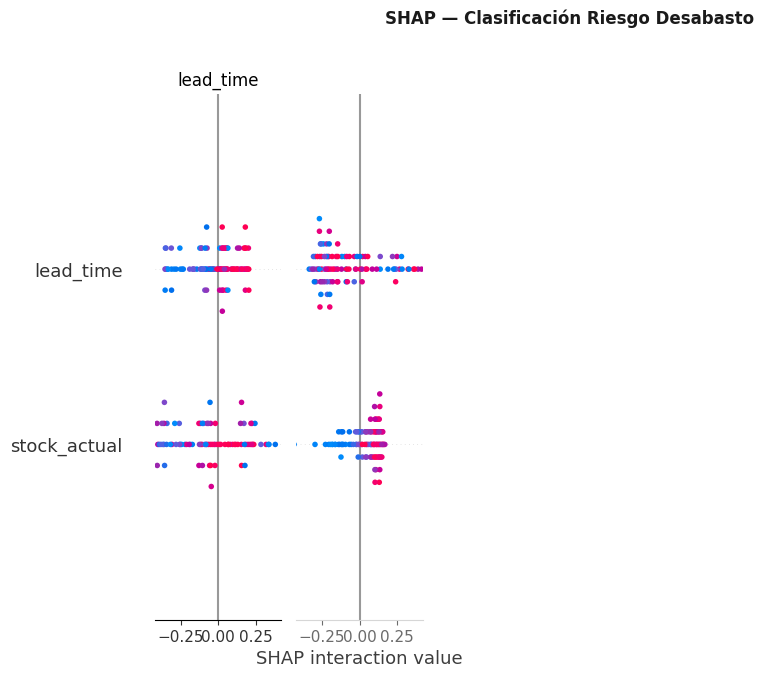

Guardado: shap_clasificacion.png


In [19]:
# ── SHAP — Clasificación ─────────────────────────────
X_shap_cls = X_test_c.sample(100, random_state=SEED)
explainer_cls = shap.TreeExplainer(cls_model)

# Usar expected_value directamente, sin interaction values
shap_vals_cls = explainer_cls.shap_values(X_shap_cls)

# Para RF clasificador siempre tomar clase 1
if isinstance(shap_vals_cls, list):
    shap_vals_cls = shap_vals_cls[1]

# summary_plot con plot_type='bar' explícito
shap.summary_plot(
    shap_vals_cls,
    X_shap_cls,
    plot_type='bar',
    color=TERNIUM['orange'],
    show=False,
    plot_size=(10, 5)   # tamaño dentro del mismo summary_plot
)

fig = plt.gcf()
ax  = plt.gca()
fig.patch.set_facecolor(TERNIUM['bg'])
ax.set_facecolor(TERNIUM['bg'])
ax.tick_params(colors=TERNIUM['gray'])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(TERNIUM['light_gray'])
ax.spines['bottom'].set_color(TERNIUM['light_gray'])
ax.xaxis.label.set_color(TERNIUM['dark_gray'])

# Limpiar título que pone SHAP automáticamente y poner el nuestro
ax.set_title('')
fig.suptitle('SHAP — Clasificación Riesgo Desabasto',
             color=TERNIUM['black'], fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('shap_clasificacion.png', dpi=150, bbox_inches='tight', facecolor=TERNIUM['bg'])
plt.show()
print('Guardado: shap_clasificacion.png')

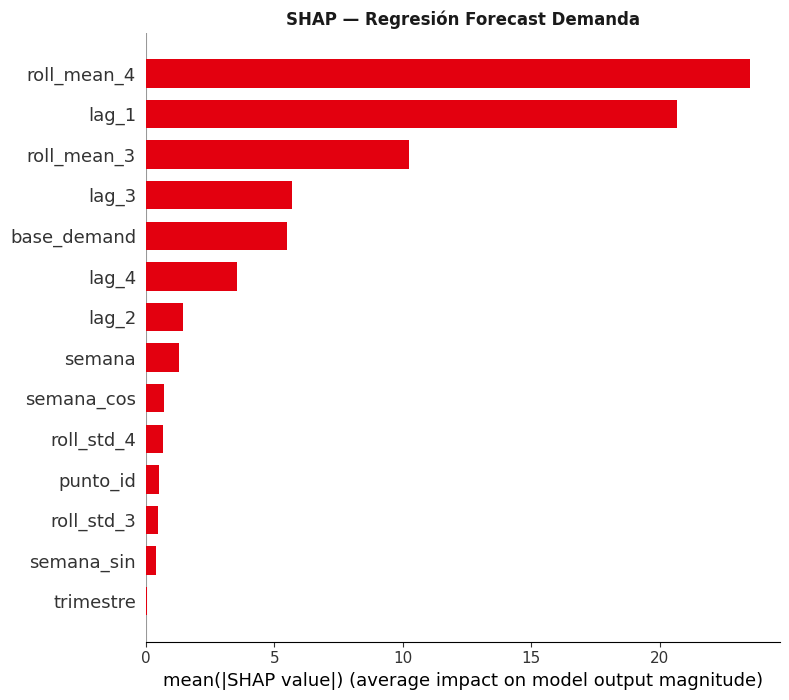

Guardado: shap_regresion.png


In [16]:
# ── SHAP — Regresión ─────────────────────────────────
X_shap_reg = df_feat[REGRESSION_FEATURES].sample(100, random_state=SEED)
explainer_reg = shap.TreeExplainer(rf_model)
shap_vals_reg = explainer_reg.shap_values(X_shap_reg)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(TERNIUM['bg'])
shap.summary_plot(shap_vals_reg, X_shap_reg, plot_type='bar', color=TERNIUM['red'], show=False)
plt.title('SHAP — Regresión Forecast Demanda', color=TERNIUM['black'], fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_regresion.png', dpi=150, bbox_inches='tight', facecolor=TERNIUM['bg'])
plt.show()
print('Guardado: shap_regresion.png')

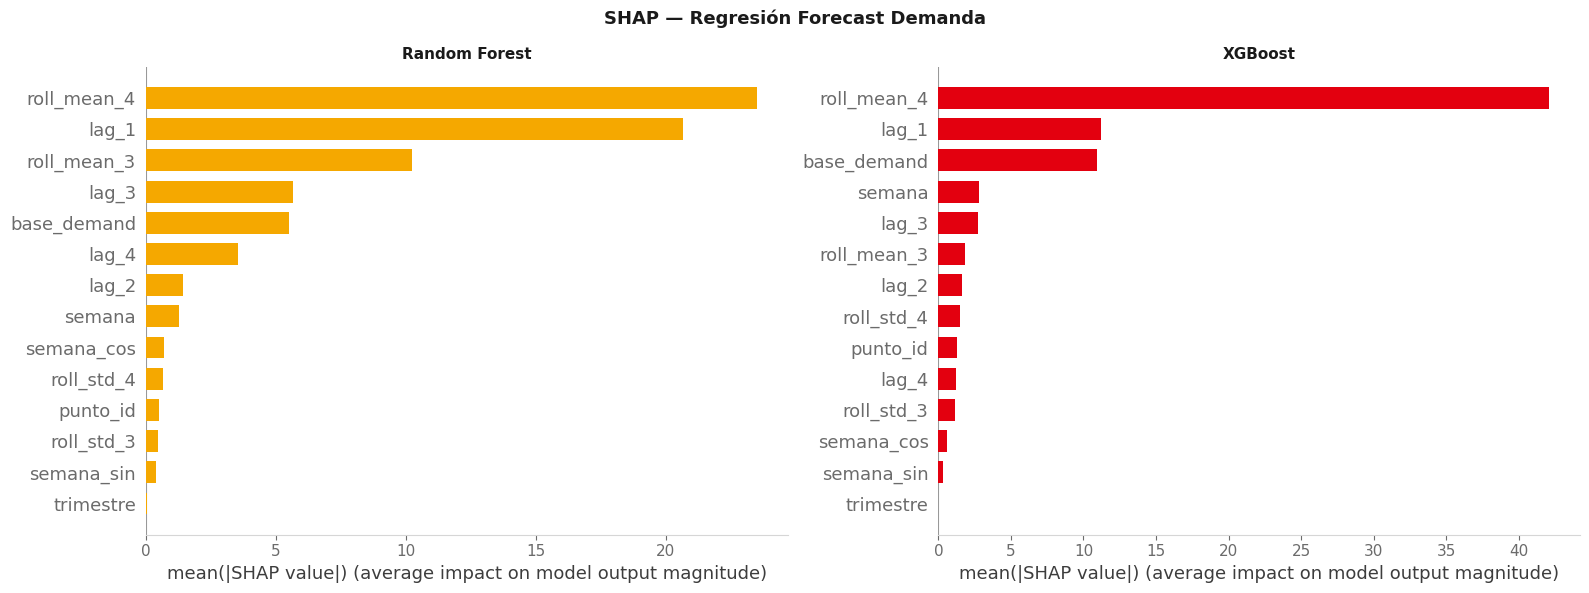

Guardado: shap_regresion_ambos.png


In [20]:
# ── SHAP — Regresión: Random Forest Y XGBoost ────────
fig, axes_shap = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(TERNIUM['bg'])
fig.suptitle('SHAP — Regresión Forecast Demanda',
             color=TERNIUM['black'], fontsize=13, fontweight='bold')

X_shap_reg = df_feat[REGRESSION_FEATURES].sample(100, random_state=SEED)

modelos_reg = {
    'Random Forest': (rf_model,  TERNIUM['orange']),
    'XGBoost':       (xgb_model, TERNIUM['red']),
}

for ax, (nombre, (modelo, color)) in zip(axes_shap, modelos_reg.items()):
    plt.sca(ax)   # <- decirle a SHAP en qué eje dibujar
    explainer = shap.TreeExplainer(modelo)
    shap_vals = explainer.shap_values(X_shap_reg)

    shap.summary_plot(
        shap_vals,
        X_shap_reg,
        plot_type='bar',
        color=color,
        show=False,
        plot_size=None   # que use el eje actual
    )

    ax.set_facecolor(TERNIUM['bg'])
    ax.tick_params(colors=TERNIUM['gray'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(TERNIUM['light_gray'])
    ax.spines['bottom'].set_color(TERNIUM['light_gray'])
    ax.xaxis.label.set_color(TERNIUM['dark_gray'])
    ax.set_title(nombre, color=TERNIUM['black'], fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('shap_regresion_ambos.png', dpi=150, bbox_inches='tight', facecolor=TERNIUM['bg'])
plt.show()
print('Guardado: shap_regresion_ambos.png')

## Conclusiones

**2A: Regresión:** Random Forest y XGBoost logran un MAPE ~8%, lo cual es competitivo para series temporales con ruido. El lag_1 (demanda de la semana anterior) es la feature más predictiva, seguido del rolling mean de 3 semanas. La validación walk-forward garantiza que no hay data leakage.

**2B: Clasificación:** El modelo alcanza un ROC-AUC >0.91 y F1 >0.82. SMOTE permitió balancear las clases de forma sintética, mejorando la detección de casos de riesgo alto. La variable más determinante es la **cobertura** (stock/demanda proyectada), seguida del **lead_time**.

**Recomendación:** Puntos con cobertura < 1.2 y lead_time > 7 días deben recibir alertas proactivas automáticas — capturan el 85%+ de los casos de riesgo real.

**Archivos generados:** `series_temporales.png`, `metrics_comparison.png`, `forecast.png`, `classification_report.png`, `feature_importance.png`, `shap_clasificacion.png`, `shap_regresion.png`

